# KNN

In [16]:
from datetime import datetime
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from scipy.sparse import load_npz, hstack
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import pandas as pd

## Carga del dataset

Se cargan los conjuntos de entrenamiento y prueba preprocesados del EDA:
* **Características TF-IDF:** Vectores de alta dimensionalidad generados por `TfidfVectorizer`.
* **Características adicionales:** Features generados durante el análisis exploratorio que capturan propiedades lingüísticas, lexicográficas y estructurales específicas de correos phishing.

In [17]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')
X_extra_train = pd.read_csv('datasets/X_extra_train.csv')
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

## Preprocesamiento y Estandarización

Dado que KNN calcula distancias entre vectores, no soporta valores no numéricos, también requiere estandarización para evitar que características con magnitudes mayores dominen. El pipeline utiliza:

* StandardScaler (con `mean=False`) para TF-IDF, para evitar que la matriz se haga más densa de valores.
* OneHotEncoder para características categóricas.
* StandardScaler selectivo para features numéricos: estandariza valores numéricos a la misma escala.

In [18]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
scaler_num = StandardScaler(with_mean=False)
scaler_tfidf = StandardScaler(with_mean=False)

tf = ColumnTransformer(transformers=[
    ('bin', 'passthrough', ['has_link', 'domain_dot_high', 'has_suspicious_tags']),
    ('cat', ohe, ['words_count_cat']),
    ('num', scaler_num, ['imperative_verbs_count', 'pronoun_density', 'urgency_markers_count'])
],
remainder='drop')

X_train = scaler_tfidf.fit_transform(X_train)
X_test = scaler_tfidf.transform(X_test)

X_extra_train = tf.fit_transform(X_extra_train)
X_extra_test = tf.transform(X_extra_test)

X_train = hstack([X_train, X_extra_train])
X_test = hstack([X_test, X_extra_test])

## Modelo Base: KNN con k=5
Se inicia con _k = 5_ como baseline. Este valor es bajo (menos regularización, mayor capacidad de ajuste local) para establecer punto de partida.

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=5)

start_train_time = datetime.now()
knn_model.fit(X_train, y_train)
end_train_time = datetime.now()

train_duration = end_train_time - start_train_time

start_predict_duration = datetime.now()
y_pred = knn_model.predict(X_test)
end_predict_duration = datetime.now()

predict_duration = end_predict_duration - start_predict_duration

## Evaluación del Modelo Base

Se evalúa el desempeño del modelo mediante una matriz de confusión y métricas de clasificación. Dado que hay cierto desbalance de clases en el problema (aproximadamente 38% de correos son phishing), se utiliza la exactitud balanceada.

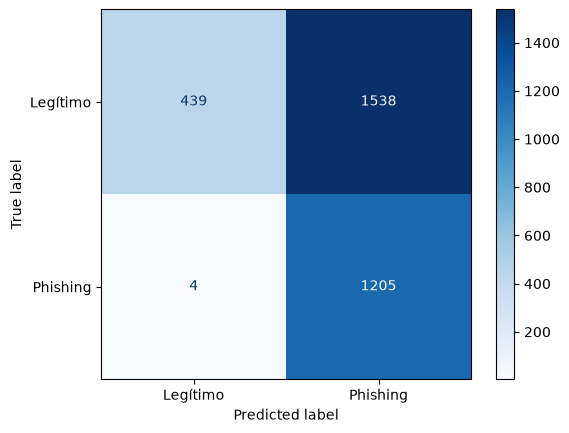

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [21]:
cm_knn = confusion_matrix(y_test, y_pred)
P = cm_knn[1, :].sum()
N = cm_knn[0, :].sum()
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]

TPR_knn = TP / P
TNR_knn = TN / N
balanced_accuracy_knn = (TPR_knn + TNR_knn) / 2

precision_knn = precision_score(y_test, y_pred, zero_division=0)
recall_knn = recall_score(y_test, y_pred, zero_division=0)
f1_knn = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_knn:.4f}")
print(f"Precisión:               {precision_knn:.4f}")
print(f"Sensibilidad (Recall):   {TPR_knn:.4f}")
print(f"F1-score:                {f1_knn:.4f}")
print(f"Especificidad:           {TNR_knn:.4f}")
print(f"Recuperación (Recall):   {recall_knn:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.6094
Precisión:               0.4393
Sensibilidad (Recall):   0.9967
F1-score:                0.6098
Especificidad:           0.2221
Recuperación (Recall):   0.9967
Tiempo de entrenamiento: 0:00:00.045064
Tiempo de predicción:    0:00:01.735757


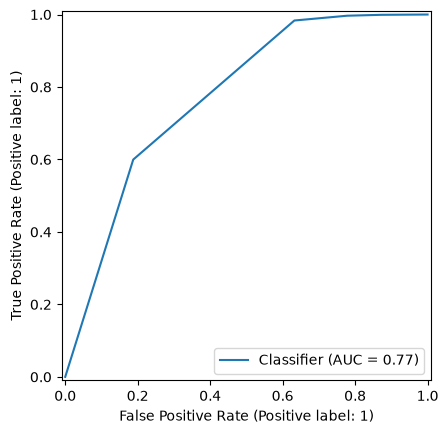

In [22]:
y_scores = knn_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Claramente son resultados iniciales de un baseline. El inconveniente es que marcar tantos emails legítimos como spam es un problema serio.

## Optimización de parámetros

Aunque KNN es conceptualmente simple, se puede ajustar su comportamient medianto los hiperparámetros:

* `n_neighbors` (k): El número de vecinos considerados para la votación. Valores bajos pueden capturar ruido local, mientras que valores grandes pueden suavizar mucho las fronteras de decisión.
* `weights`: La ponderación de los vecinos puede asignar el mismo peso a todos los vecinos o penalizar los más lejanos.
* `metric`: La métrica de distancia utilizada. Euclidiana es la más común y la que se usa por defecto en la librería, por ende, en el resultado baseline.

Se utiliza el framework Optuna. El objetivo es maximizar el F1-score en validación cruzada (3-fold).

In [23]:
def objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 50)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"])

    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)

    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()

def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value)
            improvement_percent *= 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} "
                f"with {improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: " 
            f"{frozen_trial.value}")

optuna.logging.set_verbosity(optuna.logging.ERROR)

Se ejecutan 100 trials.

In [24]:
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.HyperbandPruner)
start_train_time_opt = datetime.now()
study.optimize(objective, n_trials=100, callbacks=[champion_callback], n_jobs=-1)
end_train_time_opt = datetime.now()

train_duration_opt = end_train_time_opt - start_train_time_opt

Initial trial 3 achieved value: 0.5707522367971879
Trial 0 achieved value: 0.9069686135359586 with  37.0703% improvement
Trial 59 achieved value: 0.9162313599557735 with  1.0110% improvement
Trial 68 achieved value: 0.9173118335537062 with  0.1178% improvement
Trial 69 achieved value: 0.917785766839056 with  0.0516% improvement


In [25]:
best_params = study.best_params
best_params

{'n_neighbors': 48, 'weights': 'distance', 'metric': 'cosine'}

## Entrenamiento con Parámetros Optimizados

Una vez identificados los mejores hiperparámetros, se entrena un nuevo modelo KNN con la configuración óptima. Los tiempos de entrenamiento y predicción se registran para evaluar la eficiencia computacional del modelo optimizado.

In [26]:
optimized_knn_model = KNeighborsClassifier(**best_params)

start_train_time_opt = datetime.now()
optimized_knn_model.fit(X_train, y_train)
end_train_time_opt = datetime.now()

train_duration_opt = train_duration_opt + (end_train_time_opt - start_train_time_opt)

start_predict_duration_opt = datetime.now()
y_pred = optimized_knn_model.predict(X_test)
end_predict_duration_opt = datetime.now()

predict_duration_opt = end_predict_duration_opt - start_predict_duration_opt

Se evalúa el modelo optimizado sobre el conjunto de prueba y se comparan los resultados con el modelo base.

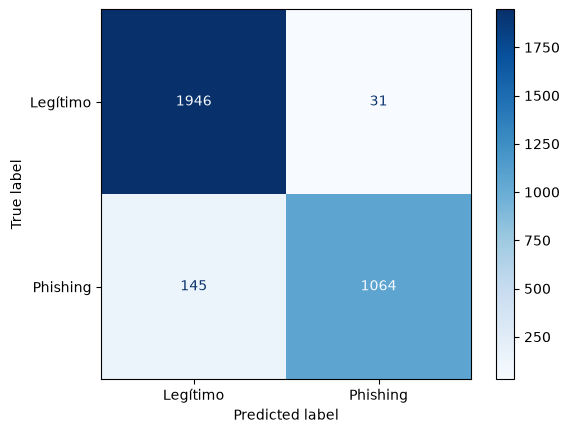

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [28]:
cm_optimized_knn = confusion_matrix(y_test, y_pred)
P_opt = cm_optimized_knn[1, :].sum()
N_opt = cm_optimized_knn[0, :].sum()
TP_opt = cm_optimized_knn[1, 1]
TN_opt = cm_optimized_knn[0, 0]

TPR_knn_opt = TP_opt / P_opt
TNR_knn_opt = TN_opt / N_opt
balanced_accuracy_knn_opt = (TPR_knn_opt + TNR_knn_opt) / 2

precision_knn_opt = precision_score(y_test, y_pred, zero_division=0)
recall_knn_opt = recall_score(y_test, y_pred, zero_division=0)
f1_knn_opt = f1_score(y_test, y_pred, zero_division=0)

print("                         Antes           Después")
print(f"Exactitud balanceada:    {balanced_accuracy_knn:.4f}          {balanced_accuracy_knn_opt:.4f}")
print(f"Precisión:               {precision_knn:.4f}          {precision_knn_opt:.4f}")
print(f"Sensibilidad (Recall):   {TPR_knn:.4f}          {TPR_knn_opt:.4f}")
print(f"F1-score:                {f1_knn:.4f}          {f1_knn_opt:.4f}")
print(f"Especificidad:           {TNR_knn:.4f}          {TNR_knn_opt:.4f}")
print(f"Recuperación (Recall):   {recall_knn:.4f}          {recall_knn_opt:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}  {train_duration_opt}")
print(f"Tiempo de predicción:    {predict_duration}  {predict_duration_opt}")

                         Antes           Después
Exactitud balanceada:    0.6094          0.9322
Precisión:               0.4393          0.9717
Sensibilidad (Recall):   0.9967          0.8801
F1-score:                0.6098          0.9236
Especificidad:           0.2221          0.9843
Recuperación (Recall):   0.9967          0.8801
Tiempo de entrenamiento: 0:00:00.045064  0:04:16.192317
Tiempo de predicción:    0:00:01.735757  0:00:01.587891


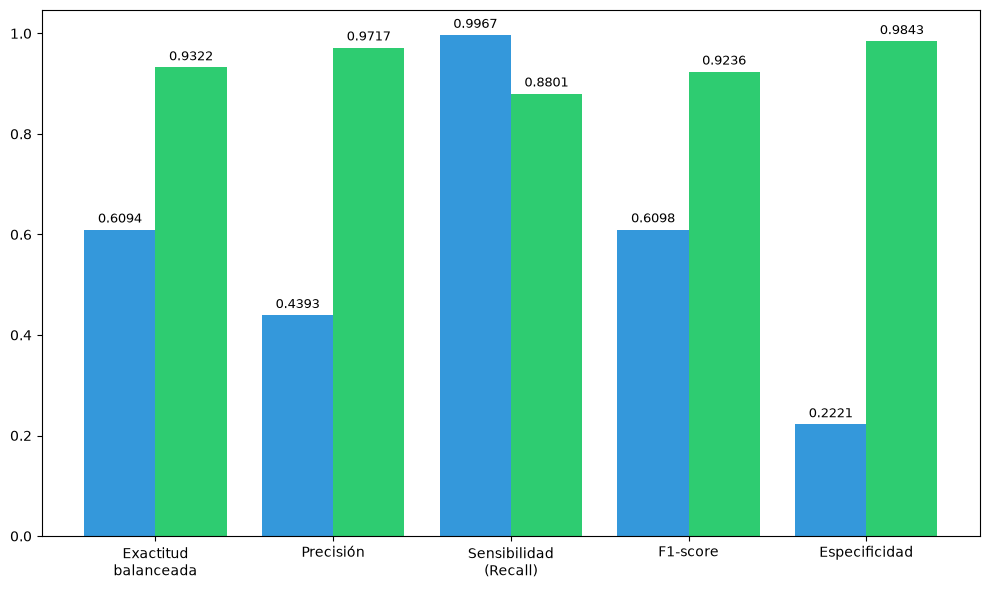

In [29]:
metrics_names = [
    'Exactitud\nbalanceada', 
    'Precisión', 
    'Sensibilidad\n(Recall)', 
    'F1-score', 
    'Especificidad'
]

before_vals = [
    balanced_accuracy_knn, 
    precision_knn, 
    TPR_knn, 
    f1_knn, 
    TNR_knn
]

after_vals = [
    balanced_accuracy_knn_opt, 
    precision_knn_opt, 
    TPR_knn_opt, 
    f1_knn_opt, 
    TNR_knn_opt
]

x = np.arange(5)

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - 0.2, before_vals, 0.4, color='#3498db')
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)
rects2 = ax.bar(x + 0.2, after_vals, 0.4, color='#2ecc71')
for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=10)

plt.tight_layout()
plt.show()


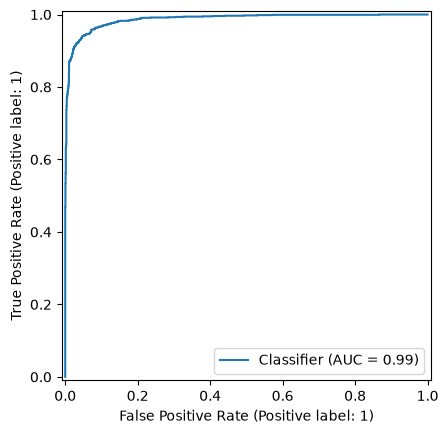

In [30]:
y_scores = optimized_knn_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

## Análisis de Resultados y Conclusiones

La ejecución realizada en este notebook muestra que el modelo base con tiene un desempeño débil, y que la optimización de hiperparámetros introduce una mejora sustancial.

El modelo base tenía una muy buena sensibilidad, generaba muchos falsos positivos; algo grave en problemas como este. La optimización corrige el desbalance fuertemente con una especificidad de 0.22 a 0.98 y una precisión de 0.44 a 0.96 a costa de una pequeña disminución de la sensibilidad.

Se puede ver que usar vecindarios más amplios (k = 48) disminuye el impacto del ruido local, ponderar la distancia evita el impacto de la interferencia que vecinos lejanos irrelevantes puede introducir y la distancia coseno indica que en espacios de alta dimensionalidad la dirección del vector captura mejar la similitud temática entre textos. Cabe destacar que, en cuanto a tiempos de entrenamiento, el modelo optimizado tuvo un costo mucho mayor (4 minutos contra menos de un segundo).